# Example 12a: Physics-Only Surrogates with the DD-PINN

Most of this curriculum learns a model from measured input-output data. This
example is different: we train a continuous-time surrogate of a dynamical system
from its **governing equations alone** — no training data at all. The only thing
you provide is the ODE residual.

Unlike examples [12](12_pinn.ipynb) and [12b](12b_ddpinn_vs_pirnn.ipynb), which use
the mass-spring-damper system, this example works on a generic forced damped
oscillator so it can showcase **conditioning**: the surrogate generalizes over the
natural frequency ω instead of learning one fixed system. Example 12b then
re-instantiates the DD-PINN on example 12's spring-damper for a head-to-head
comparison with the PIRNN.

The tool is a **DD-PINN** (a physics-informed network with a *damped ansatz*).
Given an initial state `x_k`, a constant control `u`, conditioning variables, and
a continuous time `t`, it predicts the state `x(t)`. Iterated autoregressively —
predict over `[0, T]`, take `x(T)` as the next `x_k` — it becomes a fast
simulator you can roll out for arbitrarily long horizons.

Two properties make the ansatz special, and both are baked into the model
architecture rather than learned:

1. **The initial condition is exact by construction:** `x(0) = x_k` always.
2. **The time-derivative `dx/dt` is closed-form** — so the physics residual needs
   no autograd over time, which makes training fast and validation cheap.

## Prerequisites

Comfort with the training loop from earlier examples helps, but this regime is
self-contained. Install the library with `uv sync --extra dev`.

## Setup

We cap the intra-op thread count: these collocation batches are tiny, so on CPU
the per-op thread-dispatch overhead dominates actual compute and a single thread
is markedly faster. On GPU this is irrelevant.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from scipy.integrate import solve_ivp

from tsfast.pinn import DampedAnsatzPINN, SurrogatePINNLearner

torch.set_num_threads(1)
torch.manual_seed(0)

## The damped ansatz

The model maps `(x_k, cond)` through an MLP trunk to the coefficients of a small
basis of damped sinusoids; time enters only through the closed form

$$ x(\tau) = x_k + \sum_k a_k\,\big(\sin(b_k\tau + c_k)\,e^{-d_k\tau} - \sin(c_k)\big). $$

The `-\sin(c_k)` term forces every basis function to vanish at `\tau = 0`, which
is what makes `x(0) = x_k` exact. The two properties below are not approximations
the network has to learn — they hold at initialization.

In [2]:
demo = DampedAnsatzPINN(n_state=2, n_cond=2, n_ansatz=16)

# Initial condition is exact: set t -> tau = 0, output must equal x_k.
# Input row is [x_k (2) | cond (2) | t (1)] -> width 5.
x = torch.randn(8, 1, 5)
x[..., -1] = demo.t_zero
ic_err = (demo(x) - x[..., :2]).abs().max().item()
print(f"max |x(0) - x_k| = {ic_err:.2e}")

# The analytic derivative matches autograd through the same closed form.
xg = torch.randn(4, 1, 5, requires_grad=True)
y, dy = demo(xg, derivative_flag=True)
(g,) = torch.autograd.grad(y[..., 0].sum(), xg)
print(f"max |analytic dx/dt - autograd| = {(dy[..., 0] - g[..., -1]).abs().max().item():.2e}")

max |x(0) - x_k| = 0.00e+00
max |analytic dx/dt - autograd| = 4.66e-09


## The physics: a controlled damped oscillator

Our system is a forced, damped harmonic oscillator with state `[q, qd]`, control
`u`, and a conditioning variable `\omega` (the natural frequency, which the
surrogate generalizes over):

$$ \dot q = qd, \qquad \dot{qd} = -\omega^2 q - 2\zeta\omega\, qd + u. $$

Two pieces are all the user has to write: a **batched residual** in physical
units, and a **collocation sampler** that draws normalized `[-1, 1]` points with
the row layout `[x_k | cond | t]`. Everything else is framework glue.

In [3]:
ZETA, T = 0.2, 0.1
state_range = [(-1.0, 1.0), (-5.0, 5.0)]  # q, qd
cond_range = [(-2.0, 2.0), (2.0, 4.0)]  # u, omega


def residual(x_phys, cond_phys, dxdt_phys):
    """Stacked first-order residual [dq - qd ; dqd - rhs], in physical units."""
    q, qd = x_phys[..., 0:1], x_phys[..., 1:2]
    dq, dqd = dxdt_phys[..., 0:1], dxdt_phys[..., 1:2]
    u, om = cond_phys[..., 0:1], cond_phys[..., 1:2]
    res = torch.cat([dq - qd, dqd - (-(om**2) * q - 2 * ZETA * om * qd + u)], dim=-1)
    return F.mse_loss(res, torch.zeros_like(res))


def generate_pinn_input(bs, seq_len, device):
    """Uniform collocation points in normalized [-1, 1] coordinates, layout [q, qd, u, omega, t]."""
    return torch.empty(bs, seq_len, 5, device=device).uniform_(-1, 1)

## Train — the whole loop is one object

`SurrogatePINNLearner` owns the normalization and the chain-rule factor (built
from the physical ranges you pass), samples fresh collocation points each epoch,
and minimizes the residual as the *primary* loss. The model itself stays in
normalized `[-1, 1]` space; your `residual` only ever sees physical quantities.

In [4]:
model = DampedAnsatzPINN(n_state=2, n_cond=2, n_ansatz=16, hidden_size=48, hidden_layer=2)
learn = SurrogatePINNLearner(
    model,
    generate_pinn_input,
    residual,
    state_range=state_range,
    cond_range=cond_range,
    t_max=T,
    steps_per_epoch=40,
    bs=512,
    val_steps=4,
    device=torch.device("cpu"),
)
learn.fit_flat_cos(10, lr=3e-3)

Epoch 1/10:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 40/40 [00:00<00:00, 812.25it/s, train=7.8591 | valid=0.4527]

Epoch 1/10: 100%|██████████| 40/40 [00:00<00:00, 807.87it/s, train=7.8591 | valid=0.4527]

Epoch 2/10:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 2/10: 100%|██████████| 40/40 [00:00<00:00, 818.02it/s, train=0.1921 | valid=0.0897]

...

Epoch 9/10: 100%|██████████| 40/40 [00:00<00:00, 808.56it/s, train=0.0159 | valid=0.0155]

Epoch 9/10: 100%|██████████| 40/40 [00:00<00:00, 803.41it/s, train=0.0159 | valid=0.0155]

Epoch 10/10:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 10/10: 100%|██████████| 40/40 [00:00<00:00, 840.43it/s, train=0.0147 | valid=0.0151]

Epoch 10/10: 100%|██████████| 40/40 [00:00<00:00, 835.34it/s, train=0.0147 | valid=0.0151]

## Verify one step against a reference integrator

The surrogate never saw data, so the honest test is the physics itself: compare a
single predicted step `x(T)` against `scipy.integrate.solve_ivp` over a cloud of
random initial states and conditions.

single-step RMSE  q: 0.0064  qd: 0.0135


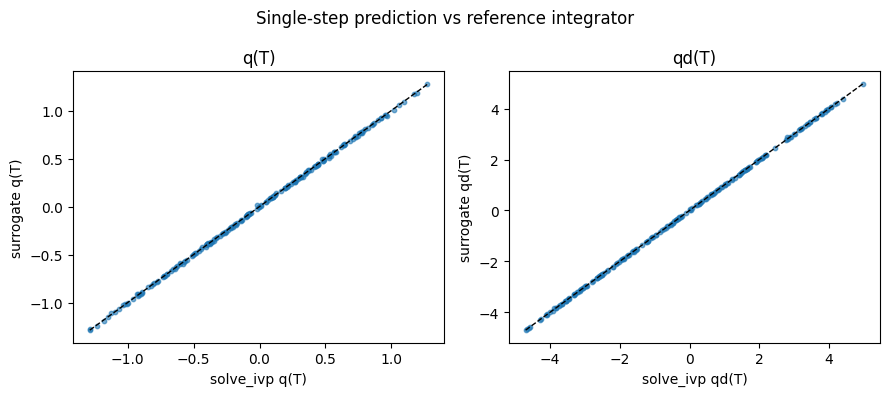

In [5]:
def norm(v, r):
    return 2 * (v - r[0]) / (r[1] - r[0]) - 1


def denorm(v, r):
    return (v + 1) / 2 * (r[1] - r[0]) + r[0]


rng = np.random.default_rng(1)
n = 200
q0, qd0 = rng.uniform(-1, 1, n), rng.uniform(-5, 5, n)
u, om = rng.uniform(-2, 2, n), rng.uniform(2, 4, n)


def rhs(t, Y):
    Y = Y.reshape(n, 2)
    return np.stack([Y[:, 1], -(om**2) * Y[:, 0] - 2 * ZETA * om * Y[:, 1] + u], 1).flatten()


ref = solve_ivp(rhs, [0, T], np.stack([q0, qd0], 1).flatten(), t_eval=[T], rtol=1e-9, atol=1e-12).y[:, -1].reshape(n, 2)

X = torch.tensor(
    np.stack(
        [
            norm(q0, state_range[0]),
            norm(qd0, state_range[1]),
            norm(u, cond_range[0]),
            norm(om, cond_range[1]),
            np.ones(n),
        ],
        1,
    ),
    dtype=torch.float32,
)[:, None, :]
with torch.no_grad():
    y = learn.model(X)[:, 0, :].numpy()
pred = np.stack([denorm(y[:, 0], state_range[0]), denorm(y[:, 1], state_range[1])], 1)
print(
    "single-step RMSE  q:",
    round(float(np.sqrt(np.mean((pred[:, 0] - ref[:, 0]) ** 2))), 4),
    " qd:",
    round(float(np.sqrt(np.mean((pred[:, 1] - ref[:, 1]) ** 2))), 4),
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, j, name in zip(axes, (0, 1), ("q(T)", "qd(T)")):
    ax.scatter(ref[:, j], pred[:, j], s=10, alpha=0.6)
    lims = [ref[:, j].min(), ref[:, j].max()]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel(f"solve_ivp {name}")
    ax.set_ylabel(f"surrogate {name}")
    ax.set_title(name)
fig.suptitle("Single-step prediction vs reference integrator")
fig.tight_layout()

## Roll it out

`learn.as_rollout(t_sample)` bundles the trained model with both scalers into a single
`DDPINNRollout` — a differentiable sequence model that takes a **physical** initial state
and a **physical** control sequence and returns the **physical** trajectory, feeding each
prediction back as the next initial state. Wrap it in `torch.no_grad()` for inference; it
is also differentiable, so the same object can drive a multi-step training loss. We compare
against the reference ODE integrated segment-by-segment with the same piecewise-constant
control.

rollout RMSE  q: 0.0088  qd: 0.0251


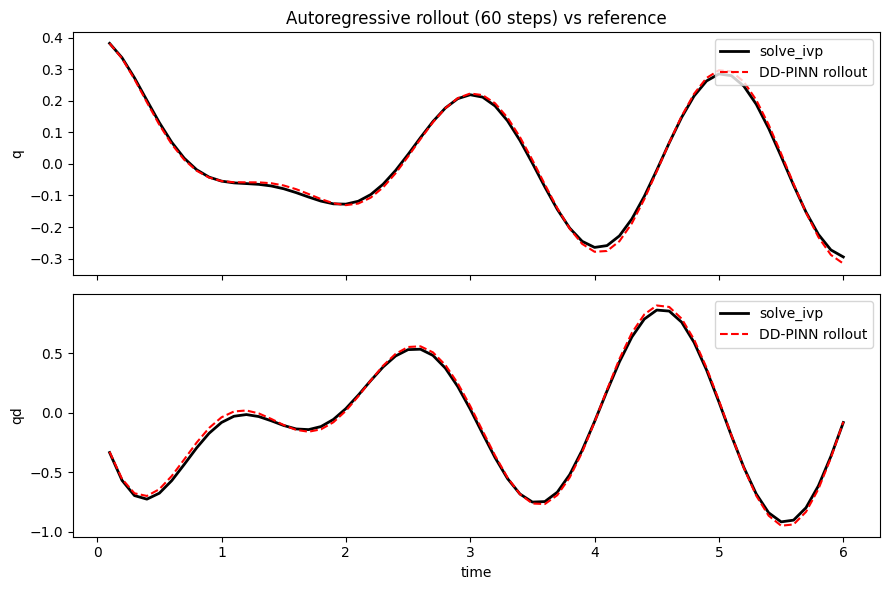

In [6]:
N = 60
om_traj = 3.0
q_init, qd_init = 0.4, 0.0
u_seq = 1.2 * np.sin(np.linspace(0, 6 * np.pi, N))  # a smooth control sweep

cond = torch.tensor(np.stack([u_seq, np.full(N, om_traj)], -1), dtype=torch.float32)[None]  # physical [1, N, 2]
x0 = torch.tensor([[q_init, qd_init]], dtype=torch.float32)  # physical [1, 2]

roll = learn.as_rollout(t_sample=T)
with torch.no_grad():
    traj = roll(x0, cond)[0].numpy()  # [N, 2] in physical units

# reference: integrate the true ODE one constant-u segment at a time
ref_traj = np.zeros((N, 2))
st = np.array([q_init, qd_init])
for k in range(N):
    st = solve_ivp(
        lambda t, Y, uk=u_seq[k]: [Y[1], -(om_traj**2) * Y[0] - 2 * ZETA * om_traj * Y[1] + uk],
        [0, T],
        st,
        t_eval=[T],
        rtol=1e-9,
        atol=1e-12,
    ).y[:, -1]
    ref_traj[k] = st

time = np.arange(1, N + 1) * T
print(
    "rollout RMSE  q:",
    round(float(np.sqrt(np.mean((traj[:, 0] - ref_traj[:, 0]) ** 2))), 4),
    " qd:",
    round(float(np.sqrt(np.mean((traj[:, 1] - ref_traj[:, 1]) ** 2))), 4),
)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for ax, j, name in zip(axes, (0, 1), ("q", "qd")):
    ax.plot(time, ref_traj[:, j], "k-", lw=2, label="solve_ivp")
    ax.plot(time, traj[:, j], "r--", lw=1.5, label="DD-PINN rollout")
    ax.set_ylabel(name)
    ax.legend(loc="upper right")
axes[-1].set_xlabel("time")
axes[0].set_title(f"Autoregressive rollout ({N} steps) vs reference")
fig.tight_layout()

## What stayed user code

Exactly two things: the **batched `residual`** (here three lines; for a real
system it is the port of your ODE) and the **per-variable physical ranges**. The
damped-ansatz model, the normalization and chain-rule bookkeeping, the
physics-only training loop, and the autoregressive rollout are all reusable
framework pieces. Swapping in a different system means rewriting `residual` and
the ranges — nothing else.